## Road to DS

## DAY_1

### Explain SQL

- Also called analyze, it's used to examine SQL execution plans
- In interviews, the focus of EXPLAIN is on indexing

In [ ]:
#  Basic syntax
EXPLAIN SELECT * FROM users Where condition

#  Can also be used in Python with DUCKDB using SQL magic after installation
%%sql explain select * from my_table

| Field              | Meaning                                                                                      |
| ------------------ | -------------------------------------------------------------------------------------------- |
| **id**             | Identifier of each part of the query; higher values indicate higher execution priority       |
| **select_type**    | Type of query, such as `SIMPLE` (simple query), `PRIMARY`, `SUBQUERY`, etc.                  |
| **table**          | Name of the table being accessed                                                             |
| **partitions**     | Partitions being accessed (if any)                                                           |
| **type**           | Join type, **a key performance indicator**. From best to worst:<br>`const` > `eq_ref` > `ref` > `range` > `index` > `ALL` |
| **possible_keys**  | Indexes that **could** be used                                                               |
| **key**            | The **actual** index used                                                                     |
| **key_len**        | Length of the index used                                                                      |
| **ref**            | Which column or constant is compared to the key                                               |
| **rows**           | Estimated number of rows to be read                                                           |
| **filtered**       | Estimated percentage of rows that pass the filter condition                                   |
| **Extra**          | Additional info such as `Using index`, `Using where`, `Using temporary`, `Using filesort`, etc. **Very important!** |


⭐type : range,index(key: index is fast),ALL

### 🧠 Optimization Examples

| Situation                          | Recommendation                                 |
| ---------------------------------- | ---------------------------------------------- |
| `type` is `ALL` (full table scan)  | Create indexes or rewrite the SQL query        |
| `Extra` shows `Using filesort`     | Add appropriate indexes to support `ORDER BY`  |
| `Extra` shows `Using temporary`    | Avoid complex `GROUP BY` or `DISTINCT` clauses |
| `key` is null                      | Index not used — optimize SQL or add indexes   |


### 🌳 BST (Binary Search Tree)

A Binary Search Tree (BST) is a special type of binary tree that satisfies the following properties:

- Each node can have at most two child nodes (left and right subtrees).
- All nodes in the left subtree have values < current node's value.
- All nodes in the right subtree have values > current node's value.
- Each subtree is also a BST.

### 🔧 Common BST Operations

| Operation     | Description                              | Time Complexity (Average) |
| ------------- | ---------------------------------------- | -------------------------- |
| **Insert**    | Insert a node into the appropriate place | O(log n)                   |
| **Search**    | Check whether a value exists             | O(log n)                   |
| **Delete**    | Delete a node and maintain BST property  | O(log n)                   |
| **Inorder Traversal** | Retrieve elements in sorted order     | O(n)                       |


### Why is BST Search Faster?

- Sequential search requires examining up to **n elements**, complexity is **O(n)**.
- BST halves the search range with each comparison, maximum steps are **log₂(n)**, i.e., **O(log n)**.
- With large datasets (e.g., millions of records), **log n grows much slower than n**, showing significant performance difference.

| Data Size (n) | Linear Search (O(n)) | BST Search (O(log n)) |
| ------------- | --------------------- | ---------------------- |
| 10            | Up to 10 comparisons  | Up to 4 comparisons    |
| 1,000         | Up to 1,000 comparisons | Up to 10 comparisons   |
| 1,000,000     | Up to 1,000,000 comparisons | Up to 20 comparisons   |


Using **BST** improves search efficiency from **linear time** to **logarithmic time**, ideal for building fast query data structures.

### Creat BST 

In [7]:
class BST:
    def __init__(self):
        self.root = None

    def insert(self, val):
        new_node = TreeNode(val)
        if not self.root:
            self.root = new_node
            return
        current = self.root
        while True:
            if val < current.val:
                if current.left is None:
                    current.left = new_node
                    return
                current = current.left
            else:
                if current.right is None:
                    current.right = new_node
                    return
                current = current.right

    # search should be O(logN) time complexity
    def search(self, val):
        current = self.root
        while current:
            if val == current.val:
                return True
            elif val < current.val:
                current = current.left
            else:
                current = current.right
        return False


## DAY_2

### SMA


$$ 
SMA_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
$$

**Explanation:**

- **SMA<sub>n</sub>(t)**: the Simple Moving Average at time *t* over a window of *n* periods  
- **P<sub>t−i</sub>**: the price at time *t − i* (typically the closing price)  
- **n**: the number of periods (e.g., 20-day average)


## EMA

$$
\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}
$$

$$
\alpha = \frac{2}{n + 1}
$$


### 📘 English Explanation

**EMA** is a weighted average that gives more importance to recent prices, reacting faster than SMA.

Where:

- $P_t$: the price at time *t* (typically closing price)  
- $\alpha = \frac{2}{n + 1}$: the smoothing factor  
- $EMA_t$: the exponential moving average at time *t*

In [12]:
pip install yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 2.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.4/118.4 kB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.3/187.3 kB 2.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 4.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.1/173.1 kB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.7/157.7 kB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.18.1-py3-none-any.whl size=138967 sha256=2061af68f0b4612c7f10013bf5bdb7b6ca3c59fb7a5b981805ab821904f95203
  Stored in di

### download and caculate data

In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
df = df[["Close"]]

# Calculate moving averages
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA60"] = df["Close"].rolling(window=60).mean()


/var/folders/b1/0fd1b6hs7lz0fm_mh346lybm0000gn/T/ipykernel_77584/1141107803.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


### Plot the closing price and moving averages

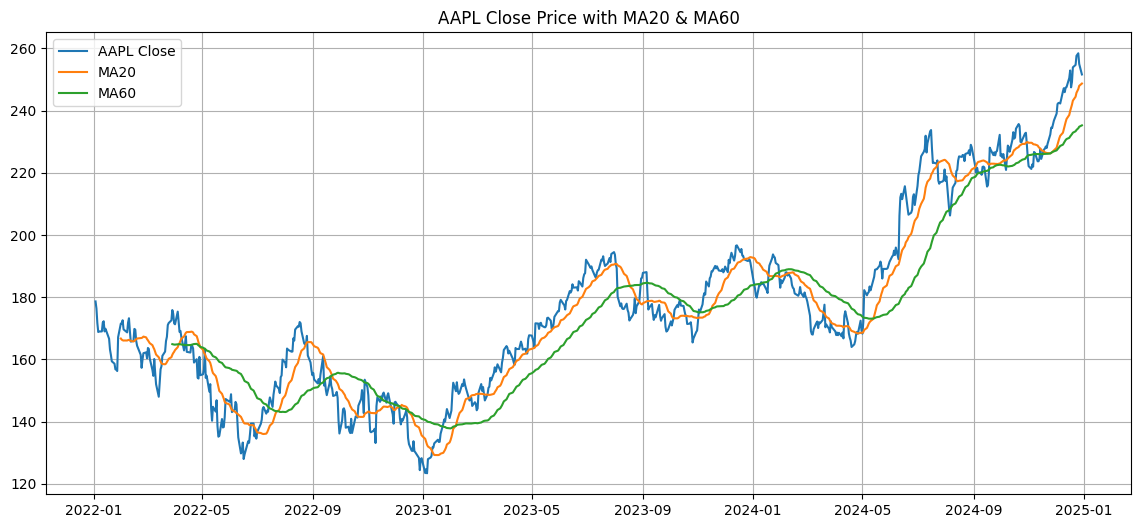

In [16]:
plt.figure(figsize=(14,6))
plt.plot(df["Close"], label="AAPL Close")
plt.plot(df["MA20"], label="MA20")
plt.plot(df["MA60"], label="MA60")
plt.legend()
plt.title("AAPL Close Price with MA20 & MA60")
plt.grid(True)
plt.show()

### Implement crossover signals

/var/folders/b1/0fd1b6hs7lz0fm_mh346lybm0000gn/T/ipykernel_77584/3394666224.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Signal"][20:] = (df["MA20"][20:] > df["MA60"][20:]).astype(int)


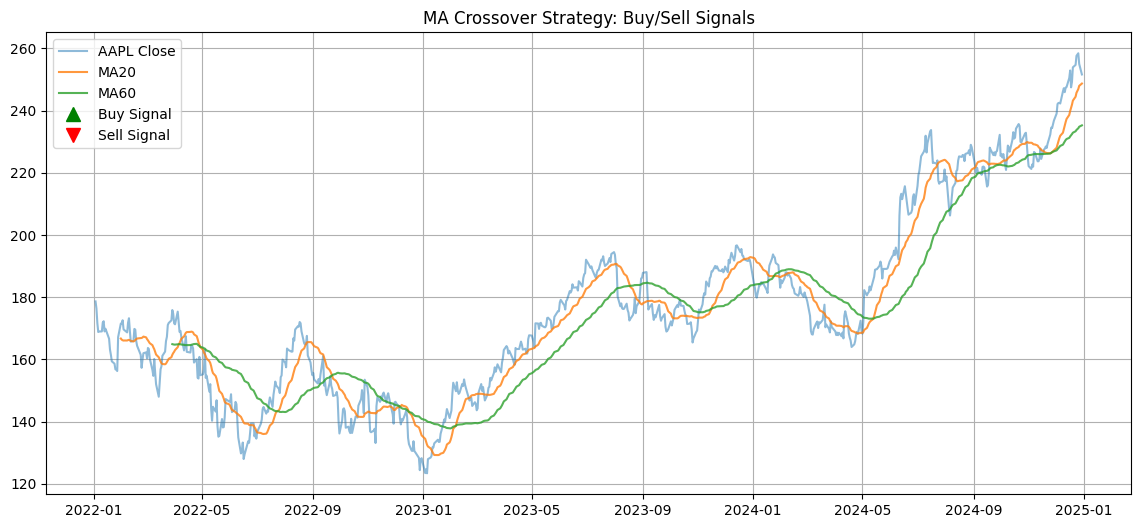

In [14]:
# Create signal column: 1 for buy, 0 for no position
df["Signal"] = 0
df["Signal"][20:] = (df["MA20"][20:] > df["MA60"][20:]).astype(int)

# Calculate the position change (1 = buy signal, -1 = sell signal)
df["Position"] = df["Signal"].diff()

# Plot buy and sell signals on the price chart
plt.figure(figsize=(14,6))
plt.plot(df["Close"], label="AAPL Close", alpha=0.5)
plt.plot(df["MA20"], label="MA20", alpha=0.8)
plt.plot(df["MA60"], label="MA60", alpha=0.8)

# Buy signals (golden cross)
plt.plot(df[df["Position"] == 1].index, 
         df[df["Position"] == 1]["Close"], 
         "^", markersize=10, color='g', label="Buy Signal")

# Sell signals (death cross)
plt.plot(df[df["Position"] == -1].index, 
         df[df["Position"] == -1]["Close"], 
         "v", markersize=10, color='r', label="Sell Signal")

plt.title("MA Crossover Strategy: Buy/Sell Signals")
plt.legend()
plt.grid(True)
plt.show()